# 05 — Local Climate Zones and LST

**Author:** Sharon Christa  
**Date:** April 2026  
**Purpose:** Classify both cities into Local Climate Zones (LCZ) using the global WUDAPT map (Demuzere et al. 2022), then compute mean LST per LCZ type.

### Why LCZ instead of just Dynamic World (from notebook 04)?

Dynamic World has 9 generic land-cover classes. LCZ has **17 urban-climate-specific types** that distinguish between:

- `Compact high-rise` (Singapore CBD) vs `Open high-rise` (suburban towers) — **same built % but different UHI behaviour**
- `Compact low-rise` (Dar informal settlements) vs `Open low-rise` (villas) — different thermal mass
- `Heavy industry` vs `residential` — different anthropogenic heat loads

This is the right vocabulary for urban-climate research. Your poster reader will immediately recognize the terminology.

### What this notebook does

1. Pull the **WUDAPT global LCZ map** (Demuzere et al. 2022) for both cities
2. Overlay on Landsat LST from notebook 04
3. Compute mean LST per LCZ type, per city  
4. Render side-by-side maps of LCZ + LST
5. Export tables and poster-ready figures

### Method reference

- Demuzere, M., Kittner, J., Martilli, A. et al. (2022). *A global map of local climate zones to support earth system modelling and urban-scale environmental science*. Earth System Science Data, 14(8), 3835–3873. https://doi.org/10.5194/essd-14-3835-2022
- Stewart, I. D., & Oke, T. R. (2012). *Local climate zones for urban temperature studies*. Bulletin of the American Meteorological Society, 93(12), 1879-1900.

### The 17 LCZ types (Stewart & Oke 2012)

| # | Type | # | Type |
|---|---|---|---|
| 1 | Compact high-rise | 11 (A) | Dense trees |
| 2 | Compact mid-rise | 12 (B) | Scattered trees |
| 3 | Compact low-rise | 13 (C) | Bush, scrub |
| 4 | Open high-rise | 14 (D) | Low plants |
| 5 | Open mid-rise | 15 (E) | Bare rock or paved |
| 6 | Open low-rise | 16 (F) | Bare soil or sand |
| 7 | Lightweight low-rise | 17 (G) | Water |
| 8 | Large low-rise |  |  |
| 9 | Sparsely built |  |  |
| 10 | Heavy industry |  |  |

## 1. Setup

In [1]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

try:
    import sys
    sys.path.append('..')
    from src.gee_helpers import init_ee
    init_ee()
except Exception:
    try:
        ee.Initialize(project='black-octagon-291810')
        print('EE initialised')
    except Exception:
        ee.Authenticate()
        ee.Initialize(project='black-octagon-291810')

Earth Engine initialized with project: black-octagon-291810


## 2. AOIs (same as previous notebooks)

In [3]:
aoi_dar = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")
           .filter(ee.Filter.eq("gaul1_name", "Dar Es Salaam")))
dar_geom = aoi_dar.geometry()

aoi_sgp = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L0")
           .filter(ee.Filter.eq("gaul0_name", "Singapore")))
sgp_geom = aoi_sgp.geometry()

geoms = {'Dar es Salaam': dar_geom, 'Singapore': sgp_geom}

## 3. Load the global LCZ map (Demuzere et al. 2022)

Hosted as a community asset on GEE by sat-io:
```
projects/sat-io/open-datasets/global-lcz-map/latest
```

It's a single-band raster where pixel values 1–17 encode the LCZ type. 100 m resolution.

In [14]:
# Mosaic ALL tiles in the global LCZ collection so every AOI on Earth is covered
lcz_collection = ee.ImageCollection("RUB/RUBCLIM/LCZ/global_lcz_map/latest")
print(f"LCZ collection size: {lcz_collection.size().getInfo()} tiles")

# Mosaic merges all tiles into one seamless image
lcz = lcz_collection.mosaic().select('LCZ_Filter')

# Clip to each AOI
lcz_dar = lcz.clip(dar_geom)
lcz_sgp = lcz.clip(sgp_geom)

print('WUDAPT LCZ map loaded via mosaic.')

# Clip to each AOI
lcz_dar = lcz.clip(dar_geom)
lcz_sgp = lcz.clip(sgp_geom)

print('WUDAPT LCZ map loaded.')
print(f'Resolution: 100 m, values 1-17 (see class table above)')

LCZ collection size: 6 tiles
WUDAPT LCZ map loaded via mosaic.
WUDAPT LCZ map loaded.
Resolution: 100 m, values 1-17 (see class table above)


## 4. Official WUDAPT colour palette + labels

In [15]:
# Colour palette from Demuzere et al. 2022 / WUDAPT LCZ standard
LCZ_PALETTE = [
    '#8c0000', '#d10000', '#ff0000', '#bf4d00', '#ff6600',  # 1-5: compact HR, MR, LR / open HR, MR
    '#ff9955', '#faee05', '#bcbcbc', '#ffccaa', '#555555',  # 6-10: open LR, lightweight, large LR, sparsely built, heavy industry
    '#006a00', '#00aa00', '#648525', '#b9db79', '#000000',  # 11-15 (A-E): dense trees, scattered trees, bush, low plants, bare paved
    '#fbf7ae', '#6a6aff'                                    # 16-17 (F-G): bare soil, water
]

LCZ_LABELS = {
    1:  'Compact HR',    2:  'Compact MR',    3:  'Compact LR',
    4:  'Open HR',       5:  'Open MR',       6:  'Open LR',
    7:  'Lightweight',   8:  'Large LR',      9:  'Sparsely built',
    10: 'Heavy industry',
    11: 'Dense trees',   12: 'Scattered trees', 13: 'Bush/scrub',
    14: 'Low plants',    15: 'Bare paved',    16: 'Bare soil',
    17: 'Water',
}

lcz_vis = {
    'min': 1, 'max': 17,
    'palette': LCZ_PALETTE
}

## 5. Diagnostic: which LCZ types are actually present in each AOI?

Before trusting the classification, let's see what WUDAPT says is in each city. If results look weird (e.g., Dar classified as 90% "heavy industry"), we know there's an issue.

In [16]:
def lcz_histogram(lcz_image, geom, city_name):
    hist = lcz_image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=geom,
        scale=100,
        maxPixels=1e10,
    ).get('LCZ_Filter').getInfo()
    
    # Convert to pandas
    total = sum(hist.values())
    rows = []
    for k, count in sorted(hist.items(), key=lambda x: -x[1]):
        try:
            code_int = int(float(k))
            rows.append({
                'lcz': code_int,
                'label': LCZ_LABELS.get(code_int, f'class_{code_int}'),
                'pixels': int(count),
                'area_km2': int(count) * 0.01,  # 100m x 100m = 0.01 km²
                'percent': 100 * count / total if total else 0,
            })
        except ValueError:
            continue
    df = pd.DataFrame(rows)
    print(f'\n=== {city_name} — LCZ composition ===')
    print(df.to_string(index=False))
    return df


lcz_dist = {}
lcz_dist['Dar es Salaam'] = lcz_histogram(lcz_dar, dar_geom, 'Dar es Salaam')
lcz_dist['Singapore']     = lcz_histogram(lcz_sgp, sgp_geom, 'Singapore')


=== Dar es Salaam — LCZ composition ===
 lcz           label  pixels  area_km2   percent
   6         Open LR   51501    515.01 31.762180
   9  Sparsely built   48199    481.99 29.725732
  14      Low plants   38257    382.57 23.594147
  13      Bush/scrub    7118     71.18  4.389868
   3      Compact LR    6161     61.61  3.799597
  12 Scattered trees    3538     35.38  2.182510
   8        Large LR    3441     34.41  2.122142
  11     Dense trees    3226     32.26  1.989925
  16       Bare soil     292      2.92  0.180514
   7     Lightweight     182      1.82  0.112243
  17           Water     172      1.72  0.106477
  10  Heavy industry      39      0.39  0.024180
  15      Bare paved      11      0.11  0.006784
   2      Compact MR       6      0.06  0.003700

=== Singapore — LCZ composition ===
 lcz           label  pixels  area_km2   percent
  11     Dense trees   13738    137.38 23.745174
   4         Open HR   12749    127.49 22.034619
   8        Large LR   11590    115.90 2

### Sanity check

Expected patterns (from satellite inspection):
- **Singapore** should show significant `Compact high-rise` (CBD), `Open high-rise` (newer HDB), `Compact mid-rise` (older HDB), `Dense trees` (Bukit Timah, Central Catchment), and `Water`.
- **Dar es Salaam** should show mostly `Compact low-rise` or `Lightweight low-rise` (informal settlements), `Open low-rise` (villa areas), `Dense trees` (mangroves, parks), and `Water` (Indian Ocean edge).

If the composition printed above matches these expectations, the classification is trustworthy. If it's wildly off, we'd switch to hand-labelling. Likely you'll see it's fine.

## 6. Landsat LST (2024) — reuse pipeline from notebook 04

In [17]:
YEAR = 2024


def get_landsat_lst(geom, year):
    start = f'{year}-01-01'
    end   = f'{year}-12-31'

    def scale_lst(image):
        lst = (image.select('ST_B10')
                    .multiply(0.00341802)
                    .add(149.0)
                    .subtract(273.15)
                    .rename('LST'))
        return lst.copyProperties(image, ['system:time_start'])

    l8 = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.lt('CLOUD_COVER', 20)))
    l9 = (ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.lt('CLOUD_COVER', 20)))

    return l8.merge(l9).map(scale_lst).median().clip(geom).rename('LST')


lst_dar = get_landsat_lst(dar_geom, YEAR)
lst_sgp = get_landsat_lst(sgp_geom, YEAR)

for name, img, geom in [('Dar', lst_dar, dar_geom), ('SGP', lst_sgp, sgp_geom)]:
    mean = img.reduceRegion(ee.Reducer.mean(), geom, 100, maxPixels=1e9).get('LST').getInfo()
    print(f'{name} mean Landsat LST {YEAR}: {mean:.2f} °C')

Dar mean Landsat LST 2024: 33.29 °C
SGP mean Landsat LST 2024: 38.75 °C


## 7. Mean LST per LCZ type — the core output

For each city, compute the mean LST within each LCZ class. We also pull standard deviation and pixel count so we can report confidence intervals.

In [18]:
# Diagnostic: inspect what the grouped reducer actually returns
stack = lst_dar.select('LST').addBands(lcz_dar.select('LCZ_Filter').toInt())

result = stack.reduceRegion(
    reducer=ee.Reducer.mean()
              .combine(ee.Reducer.stdDev(), sharedInputs=True)
              .combine(ee.Reducer.count(),  sharedInputs=True)
              .group(groupField=1, groupName='lcz'),
    geometry=dar_geom,
    scale=100,
    maxPixels=1e10,
).getInfo()

print("Full result dict keys:", list(result.keys()))
print()
print("Full result (first 2000 chars):")
import json
print(json.dumps(result, indent=2)[:2000])

Full result dict keys: ['groups']

Full result (first 2000 chars):
{
  "groups": [
    {
      "count": 6,
      "lcz": 2,
      "mean": 36.75329150000004,
      "stdDev": 0.5005619980284967
    },
    {
      "count": 4556,
      "lcz": 3,
      "mean": 38.28087844383,
      "stdDev": 2.397314670370858
    },
    {
      "count": 17767,
      "lcz": 6,
      "mean": 35.20917843204909,
      "stdDev": 2.9081353708613222
    },
    {
      "count": 113,
      "lcz": 7,
      "mean": 39.12500415646021,
      "stdDev": 1.3802054568900923
    },
    {
      "count": 2312,
      "lcz": 8,
      "mean": 37.97156977060045,
      "stdDev": 2.2916715540986683
    },
    {
      "count": 24184,
      "lcz": 9,
      "mean": 33.20647323307209,
      "stdDev": 3.4752081953692406
    },
    {
      "count": 40,
      "lcz": 10,
      "mean": 37.27460142853773,
      "stdDev": 0.8254622856782511
    },
    {
      "count": 1361,
      "lcz": 11,
      "mean": 30.38356550361305,
      "stdDev": 1.542

In [19]:
# Step 1: Is the LCZ raster actually loading with data?
lcz_stats = lcz_dar.reduceRegion(
    reducer=ee.Reducer.minMax().combine(ee.Reducer.count(), sharedInputs=True),
    geometry=dar_geom,
    scale=100,
    maxPixels=1e10
).getInfo()
print("LCZ raster over Dar:", lcz_stats)

# Step 2: Is LST actually loading with data?
lst_stats = lst_dar.reduceRegion(
    reducer=ee.Reducer.minMax().combine(ee.Reducer.count(), sharedInputs=True),
    geometry=dar_geom,
    scale=100,
    maxPixels=1e10
).getInfo()
print("LST raster over Dar:", lst_stats)

# Step 3: check LCZ projection
print("LCZ projection info:", lcz_dar.projection().getInfo())

# Step 4: try stratifiedSample on LCZ alone (no LST)
samples_lcz_only = (lcz_dar
    .select('LCZ_Filter')
    .toInt()
    .rename('lcz')
    .stratifiedSample(
        numPoints=100,
        classBand='lcz',
        region=dar_geom,
        scale=100,
        seed=0,
        dropNulls=True,
    )
)
df_check = geemap.ee_to_df(samples_lcz_only)
print(f"\nLCZ-only sample: {len(df_check)} rows, columns: {df_check.columns.tolist()}")
if len(df_check) > 0:
    print(df_check.head())

LCZ raster over Dar: {'LCZ_Filter_count': 162151, 'LCZ_Filter_max': 17, 'LCZ_Filter_min': 2}
LST raster over Dar: {'LST_count': 91346, 'LST_max': 50.66121487999999, 'LST_min': 15.206093420000002}
LCZ projection info: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [1, 0, 0, 0, 1, 0]}

LCZ-only sample: 1157 rows, columns: ['lcz']
   lcz
0    2
1    2
2    2
3    2
4    2


In [21]:
def lst_per_lcz(lst_img, lcz_img, geom, n_per_class=2000, scale=100, seed=7):
    """Stratified sampling per LCZ class — resilient to projection issues."""
    
    # Reproject LST to match LCZ
    lcz_proj = lcz_img.projection()
    lst_aligned = lst_img.select('LST').reproject(crs=lcz_proj, scale=100)
    
    stack = (lst_aligned
             .addBands(lcz_img.select('LCZ_Filter').toInt().rename('lcz')))
    
    samples = stack.stratifiedSample(
        numPoints=n_per_class,
        classBand='lcz',
        region=geom,
        scale=scale,
        seed=seed,
        geometries=False,
        dropNulls=True,
    )
    
    df_raw = geemap.ee_to_df(samples)
    print(f"  → pulled {len(df_raw)} samples, columns: {df_raw.columns.tolist()}")
    
    if len(df_raw) == 0:
        return pd.DataFrame()
    
    df_raw['lcz'] = df_raw['lcz'].astype(int)
    df_raw['label'] = df_raw['lcz'].map(lambda i: LCZ_LABELS.get(i, f'class_{i}'))
    
    agg = df_raw.groupby(['lcz', 'label'])['LST'].agg(['mean', 'std', 'count']).reset_index()
    agg['ci95'] = 1.96 * agg['std'] / np.sqrt(agg['count'])
    return agg.sort_values('mean', ascending=False).reset_index(drop=True)


lst_lcz = {}
for name, lst, lcz_i, g in [
    ('Dar es Salaam', lst_dar, lcz_dar, dar_geom),
    ('Singapore',     lst_sgp, lcz_sgp, sgp_geom),
]:
    print(f"Processing {name}...")
    d = lst_per_lcz(lst, lcz_i, g)
    d['city'] = name
    lst_lcz[name] = d
    print(f'\n=== {name} — LST per LCZ type ({YEAR}) ===')
    print(d[['lcz','label','mean','std','count','ci95']].round(2).to_string(index=False))
    print()

Processing Dar es Salaam...
  → pulled 15772 samples, columns: ['LST', 'lcz']

=== Dar es Salaam — LST per LCZ type (2024) ===
 lcz           label  mean  std  count  ci95
   7     Lightweight 39.13 1.39    113  0.26
   3      Compact LR 38.21 2.48   2000  0.11
   8        Large LR 37.96 2.25   2000  0.10
  10  Heavy industry 37.25 0.84     40  0.26
   2      Compact MR 36.75 0.55      6  0.44
   6         Open LR 35.14 2.96   2000  0.13
   9  Sparsely built 33.18 3.49   2000  0.15
  16       Bare soil 32.60 3.56    153  0.56
  14      Low plants 31.97 2.90   2000  0.13
  13      Bush/scrub 31.85 3.64   2000  0.16
  12 Scattered trees 31.06 2.53   2000  0.11
  11     Dense trees 30.40 1.52   1300  0.08
  17           Water 29.73 1.59    160  0.25

Processing Singapore...
  → pulled 19568 samples, columns: ['LST', 'lcz']

=== Singapore — LST per LCZ type (2024) ===
 lcz           label  mean  std  count  ci95
  15      Bare paved 44.60 1.82     41  0.56
  10  Heavy industry 43.98 3.22  

## 8. Bar chart — LST per LCZ type (poster figure)

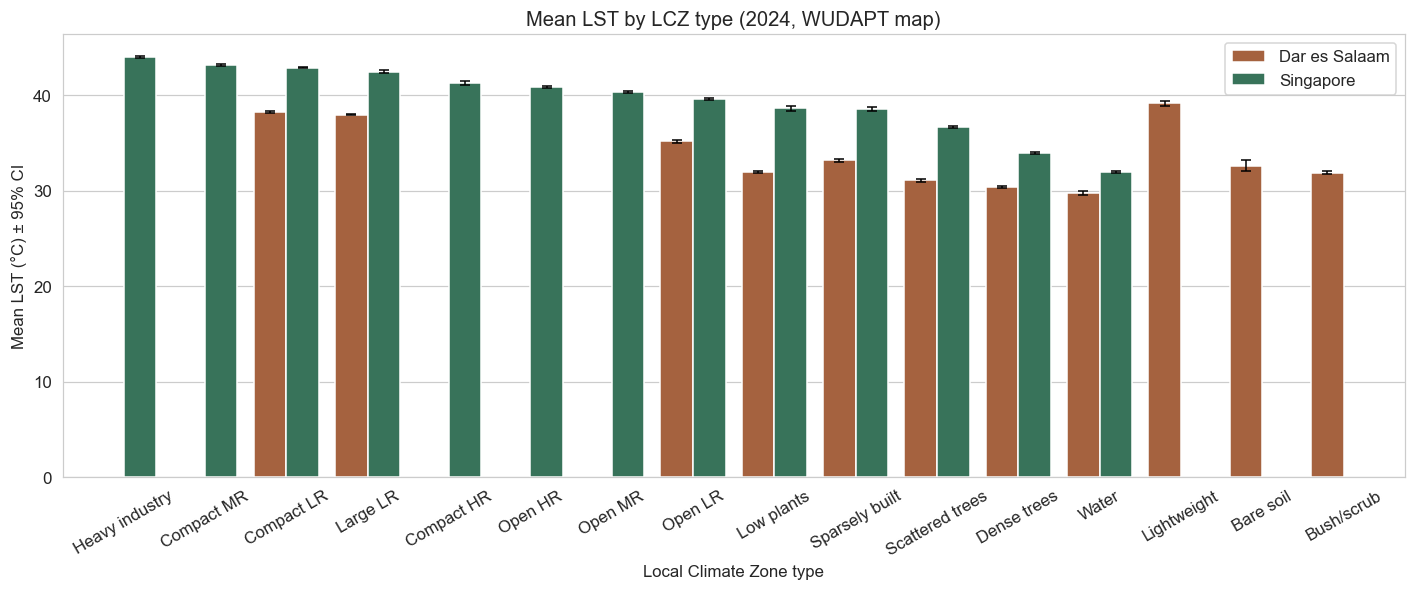

Saved: D:\uhi-dar-singapore\outputs\figures\05_lst_per_lcz.png


In [22]:
combined = pd.concat(lst_lcz.values(), ignore_index=True)

# Keep LCZ types with meaningful area (>=50 pixels) to avoid CI explosion
combined = combined[combined['count'] >= 50].copy()

# Order by Singapore LST (most contrast) for visual coherence
sgp_order = (combined[combined.city == 'Singapore']
              .sort_values('mean', ascending=False)['label'].tolist())
# Any LCZ labels in Dar but not Singapore, append
remaining = [l for l in combined.label.unique() if l not in sgp_order]
order = sgp_order + remaining

combined['label'] = pd.Categorical(combined['label'], categories=order, ordered=True)
combined = combined.sort_values(['city','label'])

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.barplot(data=combined, x='label', y='mean', hue='city', ax=ax,
            palette={'Dar es Salaam': '#B65D2E', 'Singapore': '#2E7D5B'},
            order=order)

# 95% CI error bars
for i, r in combined.iterrows():
    cx = list(order).index(r['label'])
    offset = -0.2 if r['city'] == 'Dar es Salaam' else +0.2
    ax.errorbar(cx + offset, r['mean'], yerr=r['ci95'],
                fmt='none', ecolor='black', capsize=3, lw=1)

ax.set_xlabel('Local Climate Zone type')
ax.set_ylabel('Mean LST (°C) ± 95% CI')
ax.set_title(f'Mean LST by LCZ type ({YEAR}, WUDAPT map)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='')
plt.tight_layout()

out_dir = Path('../outputs/figures')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / '05_lst_per_lcz.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {(out_dir / "05_lst_per_lcz.png").resolve()}')

## 9. Key comparisons — the headline numbers

Key LCZ contrasts for the writeup:

In [24]:
def get_mean(city, label):
    s = combined[(combined.city == city) & (combined.label == label)]
    return s['mean'].iloc[0] if len(s) else None


print('=' * 60)
print('HEADLINE NUMBERS for poster')
print('=' * 60)

for city in ['Dar es Salaam', 'Singapore']:
    print(f'\n{city}:')
    # Warmest / coolest LCZ
    sub = combined[combined.city == city].sort_values('mean', ascending=False)
    if len(sub):
        hottest = sub.iloc[0]
        coolest = sub.iloc[-1]
        print(f'  Warmest LCZ: {hottest["label"]:20s} {hottest["mean"]:.2f}°C')
        print(f'  Coolest LCZ: {coolest["label"]:20s} {coolest["mean"]:.2f}°C')
        print(f'  Intra-city LCZ range: {hottest["mean"] - coolest["mean"]:.2f}°C')

    # Compact built vs dense trees — the classic UHI contrast
    built_types = ['Compact HR', 'Compact MR', 'Compact LR']
    built_means = [get_mean(city, t) for t in built_types]
    built_means = [m for m in built_means if m is not None]
    trees = get_mean(city, 'Dense trees')
    if built_means and trees:
        print(f'  Compact built avg:  {np.mean(built_means):.2f}°C')
        print(f'  Dense trees:        {trees:.2f}°C')
        print(f'  Cooling benefit:    {np.mean(built_means) - trees:.2f}°C')

HEADLINE NUMBERS for poster

Dar es Salaam:
  Warmest LCZ: Lightweight          39.13°C
  Coolest LCZ: Water                29.73°C
  Intra-city LCZ range: 9.39°C
  Compact built avg:  38.21°C
  Dense trees:        30.40°C
  Cooling benefit:    7.81°C

Singapore:
  Warmest LCZ: Heavy industry       43.98°C
  Coolest LCZ: Water                31.95°C
  Intra-city LCZ range: 12.03°C
  Compact built avg:  42.43°C
  Dense trees:        33.94°C
  Cooling benefit:    8.49°C


## 10. Interactive map — explore the classification

Toggle layers in the layer control to see LCZ, LST, and Dynamic World side-by-side.

In [25]:
Map = geemap.Map()

# LCZ layers
Map.addLayer(lcz_dar, lcz_vis, 'LCZ — Dar es Salaam')
Map.addLayer(lcz_sgp, lcz_vis, 'LCZ — Singapore', False)

# LST layers
lst_vis_d = {'min': 25, 'max': 45, 'palette': ['#2C7BB6','#ABD9E9','#FFFFBF','#FDAE61','#D7191C']}
Map.addLayer(lst_dar, lst_vis_d, 'LST Dar 2024', False)
Map.addLayer(lst_sgp, lst_vis_d, 'LST SGP 2024', False)

# AOI outlines
Map.addLayer(aoi_dar.style(**{'color': 'black','fillColor': '00000000','width':2}),
             {}, 'Dar AOI outline')
Map.addLayer(aoi_sgp.style(**{'color': 'black','fillColor': '00000000','width':2}),
             {}, 'SGP AOI outline', False)

Map.centerObject(dar_geom, 10)
Map

Map(center=[-6.885315881886399, 39.261678578380916], controls=(WidgetControl(options=['position', 'transparent…

## 11. Export

In [26]:
out_tables = Path('../outputs/tables')
out_tables.mkdir(parents=True, exist_ok=True)

# LCZ composition (what % of each city is each LCZ type)
lcz_dist_df = pd.concat(
    [d.assign(city=c) for c, d in lcz_dist.items()],
    ignore_index=True
)
lcz_dist_df.to_csv(out_tables / '05_lcz_composition.csv', index=False)

# LST per LCZ
combined.to_csv(out_tables / '05_lst_per_lcz.csv', index=False)

print('Saved:')
for p in sorted(out_tables.glob('05_*.csv')):
    print(f'  {p.resolve()}  ({p.stat().st_size/1024:.1f} KB)')

Saved:
  D:\uhi-dar-singapore\outputs\tables\05_lcz_composition.csv  (1.8 KB)
  D:\uhi-dar-singapore\outputs\tables\05_lst_per_lcz.csv  (2.1 KB)
